In [1]:
!pip install -q sahi
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import random
import shutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
MODEL_PATH = "/kaggle/input/datasets/aadeeshranjan/bestpt/best.pt"

VAL_IMAGES = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images"

LABEL_DIR = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels"

print("CUDA:", torch.cuda.is_available())

CUDA: True


In [4]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda"
)

model = YOLO(MODEL_PATH)

In [5]:
labeled_images = []

for label_file in os.listdir(LABEL_DIR):
    if os.path.getsize(os.path.join(LABEL_DIR, label_file)) > 0:
        labeled_images.append(
            label_file.replace(".txt", ".jpg")
        )

print("Labeled Images:", len(labeled_images))

Labeled Images: 3921


In [6]:
sample_images = random.sample(
    labeled_images,
    5
)
sample_images

['Japan_011700.jpg',
 'Japan_011733.jpg',
 'Japan_010053.jpg',
 'China_Drone_000943.jpg',
 'Japan_011405.jpg']

In [7]:
os.makedirs("thesis_examples", exist_ok=True)

In [8]:
for image_name in sample_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    result.export_visuals(
        export_dir="thesis_examples",
        file_name=image_name.replace(".jpg", "")
    )

    print(f"Processed: {image_name}")

Performing prediction on 4 slices.
Processed: Japan_011700.jpg
Performing prediction on 4 slices.
Processed: Japan_011733.jpg
Performing prediction on 4 slices.
Processed: Japan_010053.jpg
Performing prediction on 1 slices.
Processed: China_Drone_000943.jpg
Performing prediction on 4 slices.
Processed: Japan_011405.jpg


In [9]:
os.listdir("thesis_examples")

['China_Drone_000943.png',
 'Japan_010053.png',
 'Japan_011405.png',
 'Japan_011733.png',
 'Japan_011700.png']

China_Drone_000943.png


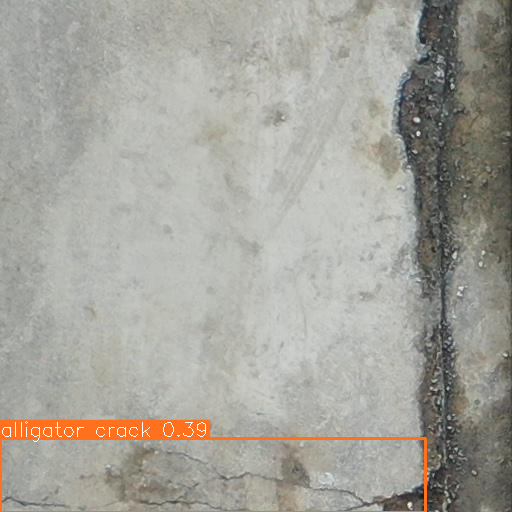

Japan_010053.png


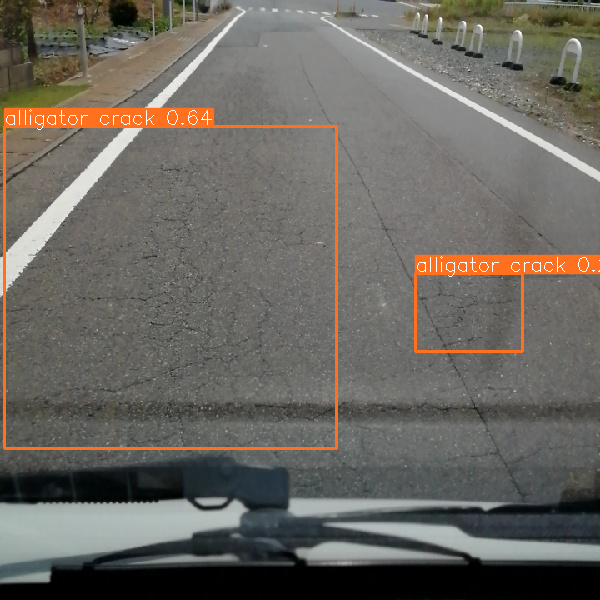

Japan_011405.png


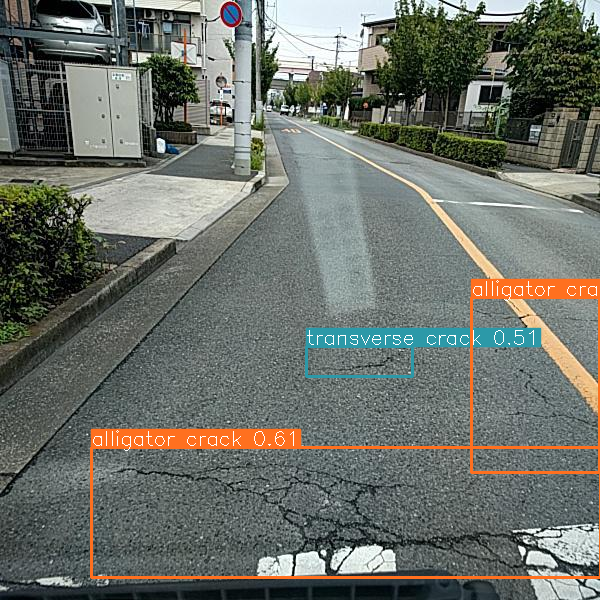

Japan_011700.png


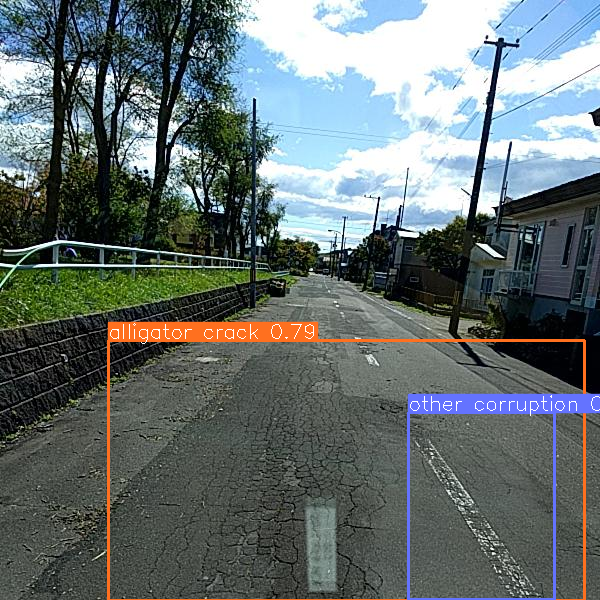

Japan_011733.png


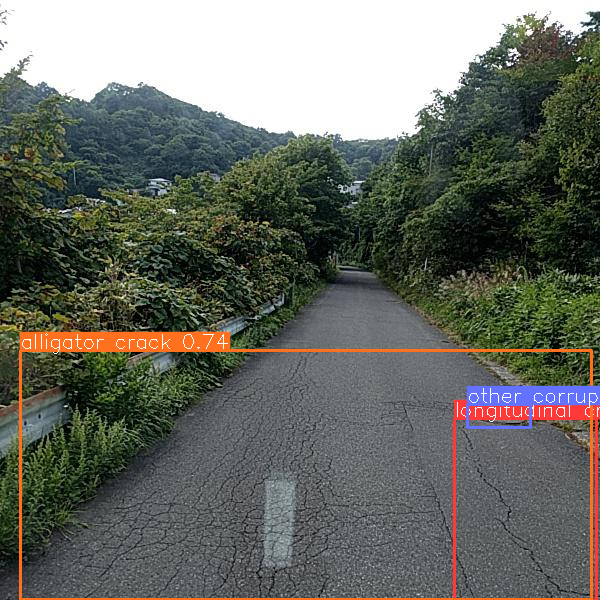

In [10]:
from PIL import Image
from IPython.display import display

for img in sorted(os.listdir("thesis_examples")):
    print(img)
    display(Image.open(os.path.join("thesis_examples", img)))

In [11]:
candidate_images = []

evaluation_subset = random.sample(
    labeled_images,
    300
)

for image_name in evaluation_subset:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    yolo_count = len(
        model(
            image_path,
            verbose=False
        )[0].boxes
    )

    sahi_count = len(
        get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        ).object_prediction_list
    )

    gain = sahi_count - yolo_count

    candidate_images.append({
        "image_path": image_path,
        "yolo": yolo_count,
        "sahi": sahi_count,
        "gain": gain
    })

candidate_images = sorted(
    candidate_images,
    key=lambda x: x["gain"],
    reverse=True
)

candidate_images[:10]

Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 50 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing predict

[{'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_007602.jpg',
  'yolo': 1,
  'sahi': 9,
  'gain': 8},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_000525.jpg',
  'yolo': 1,
  'sahi': 8,
  'gain': 7},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_004947.jpg',
  'yolo': 1,
  'sahi': 7,
  'gain': 6},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_003362.jpg',
  'yolo': 4,
  'sahi': 10,
  'gain': 6},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_005326.jpg',
  'yolo': 0,
  'sahi': 5,
  'gain': 5},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_003204.jpg',
  'yolo': 0,
  'sahi': 5,
  'gain': 5},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_005761.jpg',
  'yolo': 1,
  'sahi': 5,
  'ga

In [12]:
import os
import shutil

shutil.rmtree(
    "top_gain_comparisons",
    ignore_errors=True
)

os.makedirs(
    "top_gain_comparisons",
    exist_ok=True
)

print("Folder ready")

Folder ready


In [13]:
top_images = candidate_images[:5]

for idx, item in enumerate(
    top_images,
    start=1
):

    image_path = item["image_path"]

    yolo_result = model(
        image_path,
        verbose=False
    )[0]

    yolo_img = yolo_result.plot()

    sahi_result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    original = cv2.imread(
        image_path
    )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    vis = visualize_object_predictions(
        image=original,
        object_prediction_list=sahi_result.object_prediction_list,
        output_dir=None
    )

    sahi_img = vis["image"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,6)
    )

    axes[0].imshow(
        cv2.cvtColor(
            yolo_img,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[0].set_title(
        f"YOLO ({item['yolo']})"
    )

    axes[0].axis("off")

    axes[1].imshow(
        sahi_img
    )

    axes[1].set_title(
        f"SAHI ({item['sahi']})"
    )

    axes[1].axis("off")

    plt.tight_layout()

    plt.savefig(
        f"top_gain_comparisons/top_gain_{idx}.png",
        dpi=300
    )

    plt.close()

Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 50 slices.


In [14]:
for idx, item in enumerate(top_images, start=1):

    print(
        f"{idx}.",
        os.path.basename(item['image_path']),
        f"YOLO={item['yolo']}",
        f"SAHI={item['sahi']}",
        f"Gain={item['gain']}"
    )

1. Norway_007602.jpg YOLO=1 SAHI=9 Gain=8
2. Norway_000525.jpg YOLO=1 SAHI=8 Gain=7
3. Norway_004947.jpg YOLO=1 SAHI=7 Gain=6
4. Norway_003362.jpg YOLO=4 SAHI=10 Gain=6
5. Norway_005326.jpg YOLO=0 SAHI=5 Gain=5


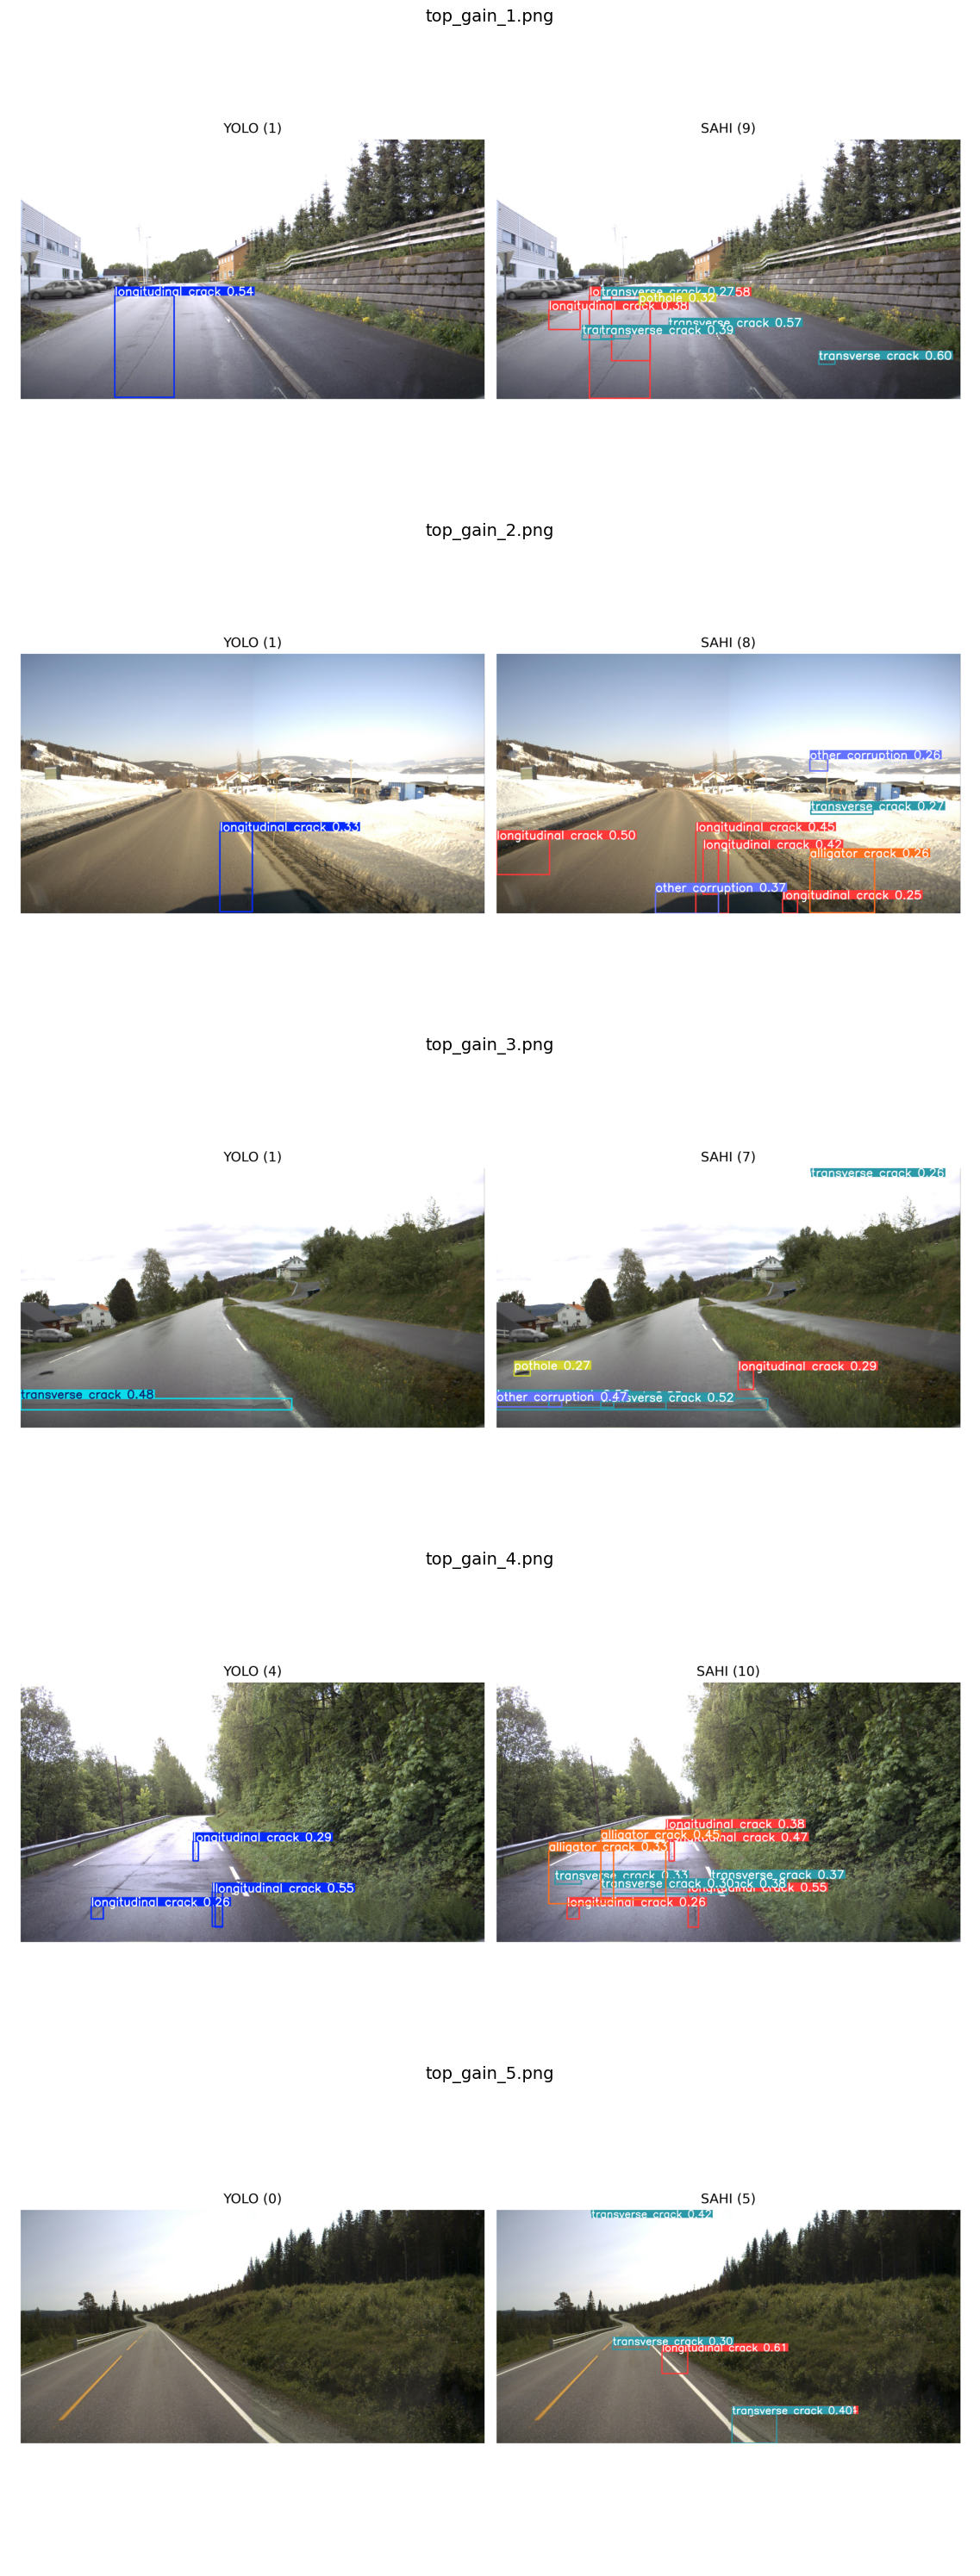

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

comparison_files = sorted(
    os.listdir("top_gain_comparisons")
)

fig, axes = plt.subplots(
    len(comparison_files),
    1,
    figsize=(14, 6 * len(comparison_files))
)

if len(comparison_files) == 1:
    axes = [axes]

for ax, file in zip(axes, comparison_files):

    img = mpimg.imread(
        os.path.join(
            "top_gain_comparisons",
            file
        )
    )

    ax.imshow(img)
    ax.set_title(file, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
subset_images = random.sample(
    labeled_images,
    2000
)

total_yolo = 0
total_sahi = 0

for image_name in subset_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    total_yolo += len(
        model(
            image_path,
            verbose=False
        )[0].boxes
    )

    total_sahi += len(
        get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        ).object_prediction_list
    )

improvement = (
    (total_sahi - total_yolo)
    / total_yolo
) * 100

print("YOLOv11s detections:", total_yolo)
print("SAHI detections:", total_sahi)
print(f"Improvement: {improvement:.2f}%")

Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 50 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing predi

In [17]:
with open("evaluation_summary.txt", "w") as f:
    f.write("Model: YOLOv11s + SAHI\n\n")
    f.write("Images Evaluated: 2000\n\n")
    f.write(f"YOLO11s Detections: {total_yolo}\n")
    f.write(f"SAHI Detections: {total_sahi}\n")
    f.write(f"Improvement (%): {improvement:.2f}\n")

In [19]:
!zip -r yolov11s_sahi_results.zip \
    thesis_examples \
    top_gain_comparisons \
    evaluation_summary.txt

  adding: thesis_examples/ (stored 0%)
  adding: thesis_examples/China_Drone_000943.png (deflated 13%)
  adding: thesis_examples/Japan_010053.png (deflated 12%)
  adding: thesis_examples/Japan_011405.png (deflated 8%)
  adding: thesis_examples/Japan_011733.png (deflated 5%)
  adding: thesis_examples/Japan_011700.png (deflated 5%)
  adding: top_gain_comparisons/ (stored 0%)
  adding: top_gain_comparisons/top_gain_2.png (deflated 2%)
  adding: top_gain_comparisons/top_gain_3.png (deflated 2%)
  adding: top_gain_comparisons/top_gain_5.png (deflated 2%)
  adding: top_gain_comparisons/top_gain_1.png (deflated 2%)
  adding: top_gain_comparisons/top_gain_4.png (deflated 2%)
  adding: evaluation_summary.txt (deflated 16%)
